# 09 — Evolução e avaliação do retrieval do RAG

Este notebook transforma a busca lexical mínima em um experimento mensurável. Ele compara BM25, embeddings com BERTimbau, busca híbrida por Reciprocal Rank Fusion (RRF) e uma versão com reranking leve por nível de evidência.

A avaliação usa 32 consultas curadas com documentos relevantes esperados. Os resultados medem retrieval, não a qualidade de uma resposta gerada por LLM.

**Objetivo e conexão com o projeto.** Esta etapa evolui a recuperação da base TOTVS e compara abordagens lexicais, vetoriais e híbridas sobre consultas com documentos esperados. A avaliação não observa apenas relevância. O contexto recuperado também precisa carregar fonte, nível de evidência e política de uso para que hipóteses não sejam apresentadas como fatos.


## 1. Decisões

- Stopwords em português são removidas apenas do índice lexical; o conteúdo original não é alterado.
- Título e produto recebem peso 3, palavras-chave peso 2 e conteúdo peso 1 no BM25.
- Aliases são aplicados tanto às consultas quanto aos documentos.
- O retriever vetorial usa mean pooling do BERTimbau base; ele é um baseline de embeddings, não um modelo especializado em similaridade de sentenças.
- A busca híbrida combina posições do BM25 e dos embeddings por RRF.
- O reranking usa um bônus pequeno para evidência mais forte e presença de fontes, sem permitir que esse bônus domine relevância.
- Recall@k, Hit@k, MRR e nDCG@k são calculados de forma reproduzível.
- Resultados destinados a contexto carregam fontes e uma política explícita para fatos, hipóteses e recomendações.

As escolhas abaixo delimitam o experimento e devem ser lidas antes da implementação. Elas registram o que o código efetivamente faz e quais limitações precisam permanecer visíveis na interpretação.


## 2. Preparação do ambiente

Nesta célula são reunidos imports, parâmetros e caminhos necessários à etapa. Centralizar essa preparação antes do processamento deixa as dependências explícitas e evita que configurações importantes fiquem dispersas entre transformações, treinamento ou avaliação.


In [ ]:
from __future__ import annotations

import json
import math
import os
import re
import tempfile
import time
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "wedjat-matplotlib"))
warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import transformers
from transformers import AutoModel, AutoTokenizer

SEED = 42
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LENGTH = 512
RRF_K = 60
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8 if DEVICE.type == "cuda" else 2


### Função auxiliar: `find_project_root`

Esta célula isola a responsabilidade implementada por `find_project_root`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Raiz do projeto não encontrada. No Colab, entre na pasta Wedjat.")


### Preparação dos objetos desta etapa

A célula prepara `ROOT`, `KB_PATH`, `ALIASES_PATH`, `QUERIES_PATH` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [1]:
ROOT = find_project_root()
KB_PATH = ROOT / "data/knowledge_base/totvs_rag_kb_v1.json"
ALIASES_PATH = ROOT / "data/knowledge_base/rag_aliases.json"
QUERIES_PATH = ROOT / "data/knowledge_base/rag_evaluation_queries.json"
EMBEDDINGS_PATH = ROOT / "data/processed/rag_bertimbau_embeddings.npz"
REPORT_PATH = ROOT / "reports/metrics/rag_retrieval_evaluation.json"
KEYWORD_AUDIT_PATH = ROOT / "reports/metrics/rag_keyword_audit.json"
FIGURE_PATH = ROOT / "reports/figures/rag_retrieval_comparison.png"

print({
    "device": str(DEVICE),
    "device_name": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU",
    "torch": torch.__version__,
    "transformers": transformers.__version__,
})


{'device': 'cuda', 'device_name': 'NVIDIA GeForce RTX 3050', 'torch': '2.14.0+cu130', 'transformers': '5.17.0'}


## 3. Carga e validação dos ativos

A execução é interrompida se houver IDs duplicados, consultas sem documento esperado ou aliases repetidos em grupos diferentes.

As verificações desta seção funcionam como critérios de integridade. Elas não melhoram as métricas por si mesmas, mas impedem que a análise prossiga silenciosamente com IDs repetidos, campos ausentes ou relações inconsistentes.


In [2]:
knowledge_base = json.loads(KB_PATH.read_text(encoding="utf-8"))
aliases_payload = json.loads(ALIASES_PATH.read_text(encoding="utf-8"))
queries_payload = json.loads(QUERIES_PATH.read_text(encoding="utf-8"))
alias_groups = aliases_payload["groups"]
evaluation_queries = queries_payload["queries"]
document_ids = [document["id"] for document in knowledge_base]
document_id_set = set(document_ids)

assert len(document_ids) == len(document_id_set), "IDs duplicados na base."
assert len({query["id"] for query in evaluation_queries}) == len(evaluation_queries)
assert all(query["expected_ids"] for query in evaluation_queries)
assert all(set(query["expected_ids"]) <= document_id_set for query in evaluation_queries)
all_aliases = [alias.casefold() for group in alias_groups for alias in [group["canonical"], *group["aliases"]]]
assert len(all_aliases) == len(set(all_aliases)), "Alias repetido em mais de um grupo."

print({
    "documents": len(knowledge_base),
    "evaluation_queries": len(evaluation_queries),
    "alias_groups": len(alias_groups),
    "expected_links": sum(len(query["expected_ids"]) for query in evaluation_queries),
})

{'documents': 107, 'evaluation_queries': 32, 'alias_groups': 29, 'expected_links': 34}


## 4. Normalização, auditoria de palavras-chave e aliases

A auditoria identifica palavras-chave vazias, formadas só por stopwords ou frequentes demais. O relatório é agregado; nenhuma alteração automática é feita na base original.

A auditoria usa apenas estrutura e valores agregados. Essa escolha permite avaliar cobertura e distribuição sem imprimir transcrições ou outros conteúdos que não devem aparecer no material entregue.


In [ ]:
PORTUGUESE_STOPWORDS = {
    "a", "ao", "aos", "aquela", "aquele", "aqueles", "as", "até", "com", "como",
    "da", "das", "de", "dela", "dele", "do", "dos", "e", "ela", "elas", "ele", "eles",
    "em", "entre", "era", "essa", "esse", "esta", "este", "eu", "foi", "isso", "isto",
    "já", "mais", "mas", "me", "mesmo", "meu", "minha", "muito", "na", "não", "nas",
    "no", "nos", "nós", "o", "os", "ou", "para", "pela", "pelo", "por", "qual",
    "que", "se", "sem", "ser", "seu", "sua", "são", "também", "tem", "um", "uma",
    "você", "vs", "x"
}


### Função auxiliar: `normalize_text`

Esta célula isola a responsabilidade implementada por `normalize_text`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def normalize_text(text: str) -> str:
    normalized = unicodedata.normalize("NFKD", str(text).casefold())
    return "".join(character for character in normalized if not unicodedata.combining(character))


### Preparação dos objetos desta etapa

A célula prepara `normalized_alias_groups` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
normalized_alias_groups = []
for group in alias_groups:
    variants = [group["canonical"], *group["aliases"]]
    normalized_alias_groups.append([normalize_text(variant) for variant in variants])


### Função auxiliar: `tokenize`

Esta célula isola a responsabilidade implementada por `tokenize`. A definição prepara essa operação para uso nas células seguintes e não altera os dados até ser chamada.


In [ ]:
def tokenize(text: str, expand_aliases: bool = True) -> list[str]:
    normalized = normalize_text(text)
    tokens = [token for token in re.findall(r"[a-z0-9+]+", normalized) if len(token) >= 2 and token not in PORTUGUESE_STOPWORDS]
    if expand_aliases:
        padded = f" {normalized} "
        for variants in normalized_alias_groups:
            if any(f" {variant} " in padded for variant in variants):
                expansion = " ".join(variants)
                tokens.extend(tokenize(expansion, expand_aliases=False))
    return tokens


### Persistência dos artefatos

Os resultados desta etapa são gravados nos caminhos definidos para consumo posterior. O conteúdo persistido segue o contrato já estabelecido pelo projeto.


In [ ]:
keyword_document_frequency = Counter()
empty_or_stopword_keywords = set()
for document in knowledge_base:
    normalized_keywords = set()
    for keyword in document.get("keywords", []):
        keyword_tokens = tokenize(keyword, expand_aliases=False)
        if not keyword_tokens:
            empty_or_stopword_keywords.add(str(keyword))
        else:
            normalized_keywords.add(" ".join(keyword_tokens))
    keyword_document_frequency.update(normalized_keywords)
common_threshold = math.ceil(len(knowledge_base) * 0.20)
overly_common_keywords = {
    keyword: frequency for keyword, frequency in keyword_document_frequency.items() if frequency >= common_threshold
}
keyword_audit = {
    "documents": len(knowledge_base),
    "unique_normalized_keywords": len(keyword_document_frequency),
    "common_threshold_documents": common_threshold,
    "empty_or_stopword_keywords": sorted(empty_or_stopword_keywords),
    "overly_common_keywords": dict(sorted(overly_common_keywords.items(), key=lambda item: (-item[1], item[0]))),
    "most_frequent_keywords": keyword_document_frequency.most_common(20),
    "decision": "Stopwords são ignoradas no índice; keywords originais permanecem intactas.",
}
KEYWORD_AUDIT_PATH.parent.mkdir(parents=True, exist_ok=True)
KEYWORD_AUDIT_PATH.write_text(json.dumps(keyword_audit, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")


### Execução da etapa

A célula aplica os objetos e funções preparados anteriormente a uma responsabilidade específica do fluxo. As saídas permanecem disponíveis para validação e interpretação nas células seguintes.


In [3]:
print({
    "unique_keywords": len(keyword_document_frequency),
    "empty_or_stopword": len(empty_or_stopword_keywords),
    "overly_common": len(overly_common_keywords),
})


{'unique_keywords': 309, 'empty_or_stopword': 19, 'overly_common': 0}


## 5. Retriever lexical BM25

BM25 considera frequência do termo, raridade na coleção e comprimento do documento. Repetimos campos conforme seus pesos antes de construir o índice.

O retriever ordena documentos candidatos para uma consulta. Esta implementação é avaliada separadamente para distinguir a qualidade da recuperação da qualidade do classificador de oportunidades.


In [ ]:
def document_text(document: dict) -> str:
    fields = [
        document.get("title", ""),
        document.get("product", ""),
        document.get("category", ""),
        " ".join(document.get("segments", [])),
        " ".join(document.get("keywords", [])),
        " ".join(document.get("related_products", [])),
        " ".join(document.get("competitors", [])),
        document.get("content", ""),
    ]
    return ". ".join(str(field) for field in fields if field)

def weighted_document_tokens(document: dict) -> list[str]:
    weighted_fields = [
        (document.get("title", ""), 3),
        (document.get("product", ""), 3),
        (" ".join(document.get("keywords", [])), 2),
        (document.get("category", ""), 1),
        (" ".join(document.get("segments", [])), 1),
        (" ".join(document.get("related_products", [])), 1),
        (" ".join(document.get("competitors", [])), 2),
        (document.get("content", ""), 1),
    ]
    result = []
    for value, weight in weighted_fields:
        result.extend(tokenize(value) * weight)
    return result


### Preparação dos objetos desta etapa

A célula prepara `bm25_document_tokens`, `bm25_term_frequencies`, `bm25_lengths`, `bm25_average_length` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
bm25_document_tokens = [weighted_document_tokens(document) for document in knowledge_base]
bm25_term_frequencies = [Counter(tokens) for tokens in bm25_document_tokens]
bm25_lengths = np.asarray([len(tokens) for tokens in bm25_document_tokens], dtype=np.float64)
bm25_average_length = float(np.mean(bm25_lengths))
bm25_document_frequency = Counter()
for tokens in bm25_document_tokens:
    bm25_document_frequency.update(set(tokens))


### Funções auxiliares da seção

Esta célula agrupa `bm25_scores`, `rank_from_scores`, definições relacionadas que permanecem dentro de um bloco legível. Elas preparam operações específicas para as células seguintes e não processam dados até serem chamadas.


In [ ]:
def bm25_scores(query: str, k1: float = 1.5, b: float = 0.75) -> np.ndarray:
    query_terms = tokenize(query)
    scores = np.zeros(len(knowledge_base), dtype=np.float64)
    for term in query_terms:
        document_frequency = bm25_document_frequency.get(term, 0)
        if document_frequency == 0:
            continue
        idf = math.log(1.0 + (len(knowledge_base) - document_frequency + 0.5) / (document_frequency + 0.5))
        for index, frequencies in enumerate(bm25_term_frequencies):
            frequency = frequencies.get(term, 0)
            if frequency:
                denominator = frequency + k1 * (1.0 - b + b * bm25_lengths[index] / bm25_average_length)
                scores[index] += idf * frequency * (k1 + 1.0) / denominator
    return scores

def rank_from_scores(scores: np.ndarray) -> list[int]:
    return np.argsort(-scores, kind="stable").tolist()


### Execução da etapa

A célula aplica os objetos e funções preparados anteriormente a uma responsabilidade específica do fluxo. As saídas permanecem disponíveis para validação e interpretação nas células seguintes.


In [4]:
print({"indexed_documents": len(bm25_document_tokens), "bm25_terms": len(bm25_document_frequency)})


{'indexed_documents': 107, 'bm25_terms': 1301}


## 6. Retriever vetorial com BERTimbau

Os vetores são normalizados e comparados por produto escalar, equivalente à similaridade de cosseno. O arquivo `.npz` fica em `data/processed/` e não é versionado.

O retriever ordena documentos candidatos para uma consulta. Esta implementação é avaliada separadamente para distinguir a qualidade da recuperação da qualidade do classificador de oportunidades.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
embedding_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
embedding_model.eval()


### Funções auxiliares da seção

Esta célula agrupa `expand_text_with_aliases`, `embed_texts`, definições relacionadas que permanecem dentro de um bloco legível. Elas preparam operações específicas para as células seguintes e não processam dados até serem chamadas.


In [ ]:
def expand_text_with_aliases(text: str) -> str:
    normalized = normalize_text(text)
    additions = []
    padded = f" {normalized} "
    for group, variants in zip(alias_groups, normalized_alias_groups):
        if any(f" {variant} " in padded for variant in variants):
            additions.append(" ".join([group["canonical"], *group["aliases"]]))
    return text if not additions else text + ". Aliases: " + ". ".join(additions)

def embed_texts(texts: list[str]) -> tuple[np.ndarray, float]:
    vectors = []
    started = time.perf_counter()
    for start in range(0, len(texts), BATCH_SIZE):
        batch = texts[start:start + BATCH_SIZE]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
        with torch.inference_mode():
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
                hidden = embedding_model(**encoded).last_hidden_state
            mask = encoded["attention_mask"].unsqueeze(-1)
            pooled = (hidden.float() * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            pooled = F.normalize(pooled, p=2, dim=1)
        vectors.append(pooled.cpu().numpy())
    return np.concatenate(vectors, axis=0), time.perf_counter() - started


### Preparação dos objetos desta etapa

A célula prepara `dense_document_texts`, `dense_score_matrix` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [5]:
dense_document_texts = [expand_text_with_aliases(document_text(document)) for document in knowledge_base]
document_embeddings, document_embedding_seconds = embed_texts(dense_document_texts)
query_embeddings, query_embedding_seconds = embed_texts([expand_text_with_aliases(item["query"]) for item in evaluation_queries])
np.savez_compressed(EMBEDDINGS_PATH, document_ids=np.asarray(document_ids), embeddings=document_embeddings)
dense_score_matrix = query_embeddings @ document_embeddings.T

print({
    "embedding_dimensions": int(document_embeddings.shape[1]),
    "document_embedding_seconds": round(document_embedding_seconds, 3),
    "query_embedding_seconds": round(query_embedding_seconds, 3),
})


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18089.48it/s]


[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'embedding_dimensions': 768, 'document_embedding_seconds': 1.272, 'query_embedding_seconds': 0.128}


## 7. Fusão híbrida e reranking por evidência

RRF combina posições, evitando comparar diretamente escalas incompatíveis de BM25 e cosseno. O bônus de evidência é deliberadamente pequeno.


In [ ]:
def reciprocal_rank_fusion(rankings: list[list[int]], rrf_k: int = RRF_K) -> np.ndarray:
    scores = np.zeros(len(knowledge_base), dtype=np.float64)
    for ranking in rankings:
        for position, document_index in enumerate(ranking, start=1):
            scores[document_index] += 1.0 / (rrf_k + position)
    return scores

def evidence_priority(document: dict) -> float:
    level = normalize_text(document.get("evidence_level", ""))
    if "fato documentado" in level:
        return 1.0
    if "fato conceitual" in level:
        return 0.9
    if "fato" in level and "inferencia" in level:
        return 0.7
    if "hipotese" in level:
        return 0.4
    if "recomendacao" in level or "validacao" in level:
        return 0.3
    return 0.5


### Preparação dos objetos desta etapa

A célula prepara `retriever_rankings` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [6]:
bm25_rankings, dense_rankings, hybrid_rankings, reranked_rankings = [], [], [], []
for query_index, query_item in enumerate(evaluation_queries):
    bm25_ranking = rank_from_scores(bm25_scores(query_item["query"]))
    dense_ranking = rank_from_scores(dense_score_matrix[query_index])
    hybrid_scores = reciprocal_rank_fusion([bm25_ranking, dense_ranking])
    reranked_scores = hybrid_scores.copy()
    for index, document in enumerate(knowledge_base):
        reranked_scores[index] += 0.00025 * evidence_priority(document)
        reranked_scores[index] += 0.00010 * bool(document.get("sources"))
    bm25_rankings.append(bm25_ranking)
    dense_rankings.append(dense_ranking)
    hybrid_rankings.append(rank_from_scores(hybrid_scores))
    reranked_rankings.append(rank_from_scores(reranked_scores))

retriever_rankings = {
    "bm25_aliases": bm25_rankings,
    "bertimbau_embeddings": dense_rankings,
    "hybrid_rrf": hybrid_rankings,
    "hybrid_evidence_rerank": reranked_rankings,
}
print({name: len(rankings) for name, rankings in retriever_rankings.items()})


{'bm25_aliases': 32, 'bertimbau_embeddings': 32, 'hybrid_rrf': 32, 'hybrid_evidence_rerank': 32}


## 8. Avaliação dos retrievers

Recall@k mede a fração dos documentos relevantes recuperada; Hit@k indica se ao menos um relevante apareceu; MRR privilegia o primeiro relevante em posição alta; nDCG considera todos os relevantes e sua ordem.

A avaliação transforma as previsões em medidas comparáveis e mantém a unidade de análise explícita. Como os rótulos atuais são automáticos, os números descrevem o experimento de desenvolvimento e não desempenho comprovado em produção.


In [ ]:
def evaluate_rankings(rankings: list[list[int]]) -> tuple[dict, list[dict]]:
    cutoffs = (1, 3, 5)
    recall_values = {cutoff: [] for cutoff in cutoffs}
    hit_values = {cutoff: [] for cutoff in cutoffs}
    ndcg_values = {cutoff: [] for cutoff in cutoffs}
    reciprocal_ranks = []
    details = []
    for query_item, ranking in zip(evaluation_queries, rankings):
        ranked_ids = [document_ids[index] for index in ranking]
        relevant = set(query_item["expected_ids"])
        relevant_positions = [position for position, document_id in enumerate(ranked_ids, start=1) if document_id in relevant]
        reciprocal_rank = 1.0 / min(relevant_positions) if relevant_positions else 0.0
        reciprocal_ranks.append(reciprocal_rank)
        query_metrics = {"query_id": query_item["id"], "expected_ids": sorted(relevant), "first_relevant_rank": min(relevant_positions) if relevant_positions else None, "top5_ids": ranked_ids[:5]}
        for cutoff in cutoffs:
            top_ids = ranked_ids[:cutoff]
            gains = [1 if document_id in relevant else 0 for document_id in top_ids]
            recall = sum(gains) / len(relevant)
            hit = float(any(gains))
            dcg = sum(gain / math.log2(position + 2) for position, gain in enumerate(gains))
            ideal_gains = [1] * min(len(relevant), cutoff)
            idcg = sum(gain / math.log2(position + 2) for position, gain in enumerate(ideal_gains))
            recall_values[cutoff].append(recall)
            hit_values[cutoff].append(hit)
            ndcg_values[cutoff].append(dcg / idcg if idcg else 0.0)
            query_metrics[f"recall@{cutoff}"] = recall
        details.append(query_metrics)
    aggregate = {"mrr": float(np.mean(reciprocal_ranks))}
    for cutoff in cutoffs:
        aggregate[f"recall@{cutoff}"] = float(np.mean(recall_values[cutoff]))
        aggregate[f"hit@{cutoff}"] = float(np.mean(hit_values[cutoff]))
        aggregate[f"ndcg@{cutoff}"] = float(np.mean(ndcg_values[cutoff]))
    return aggregate, details


### Preparação dos objetos desta etapa

A célula prepara `best_retriever` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [7]:
retrieval_metrics, query_details = {}, {}
for name, rankings in retriever_rankings.items():
    retrieval_metrics[name], query_details[name] = evaluate_rankings(rankings)
    print(name, {key: round(value, 4) for key, value in retrieval_metrics[name].items()})

best_retriever = max(retrieval_metrics, key=lambda name: (retrieval_metrics[name]["recall@5"], retrieval_metrics[name]["mrr"], retrieval_metrics[name]["ndcg@5"]))
print({"best_retriever_by_recall5_then_mrr": best_retriever})


bm25_aliases {'mrr': 0.7664, 'recall@1': 0.625, 'hit@1': 0.625, 'ndcg@1': 0.625, 'recall@3': 0.8906, 'hit@3': 0.9062, 'ndcg@3': 0.7841, 'recall@5': 0.9375, 'hit@5': 0.9688, 'ndcg@5': 0.8036}
bertimbau_embeddings {'mrr': 0.5557, 'recall@1': 0.4375, 'hit@1': 0.4375, 'ndcg@1': 0.4375, 'recall@3': 0.5938, 'hit@3': 0.5938, 'ndcg@3': 0.5279, 'recall@5': 0.6719, 'hit@5': 0.6875, 'ndcg@5': 0.5631}
hybrid_rrf {'mrr': 0.6502, 'recall@1': 0.4688, 'hit@1': 0.4688, 'ndcg@1': 0.4688, 'recall@3': 0.7969, 'hit@3': 0.8125, 'ndcg@3': 0.6657, 'recall@5': 0.8594, 'hit@5': 0.875, 'ndcg@5': 0.6913}
hybrid_evidence_rerank {'mrr': 0.6475, 'recall@1': 0.4688, 'hit@1': 0.4688, 'ndcg@1': 0.4688, 'recall@3': 0.7656, 'hit@3': 0.7812, 'ndcg@3': 0.6501, 'recall@5': 0.8594, 'hit@5': 0.875, 'ndcg@5': 0.6891}
{'best_retriever_by_recall5_then_mrr': 'bm25_aliases'}


## 9. Contrato de contexto fundamentado

O retrieval não deve apagar o nível de evidência. Cada resultado carrega URLs e uma política que a futura camada geradora deverá obedecer. Documentos sem fontes não podem sustentar afirmações factuais.


In [ ]:
def claim_policy(document: dict) -> str:
    level = normalize_text(document.get("evidence_level", ""))
    if not document.get("sources"):
        return "context_only_do_not_state_as_fact_without_source"
    if "hipotese" in level:
        return "state_only_as_hypothesis_with_citation"
    if "recomendacao" in level or "validacao" in level:
        return "state_as_recommendation_or_pending_validation_with_citation"
    return "factual_claim_requires_citation"

def retrieve_grounded(query: str, top_k: int = 5) -> list[dict]:
    bm25_ranking = rank_from_scores(bm25_scores(query))
    query_vector, _ = embed_texts([expand_text_with_aliases(query)])
    dense_ranking = rank_from_scores(query_vector @ document_embeddings.T)
    scores = reciprocal_rank_fusion([bm25_ranking, dense_ranking])
    for index, document in enumerate(knowledge_base):
        scores[index] += 0.00025 * evidence_priority(document)
        scores[index] += 0.00010 * bool(document.get("sources"))
    results = []
    for index in rank_from_scores(scores)[:top_k]:
        document = knowledge_base[index]
        results.append({
            "id": document["id"],
            "title": document["title"],
            "evidence_level": document["evidence_level"],
            "source_urls": [source["url"] for source in document.get("sources", [])],
            "claim_policy": claim_policy(document),
        })
    return results


### Verificações de integridade

As asserções tornam explícitas as condições que precisam permanecer verdadeiras para que os resultados sejam considerados consistentes.


In [8]:
grounding_validation = [retrieve_grounded(query_item["query"], top_k=5) for query_item in evaluation_queries[:3]]
assert all("claim_policy" in result and "source_urls" in result for results in grounding_validation for result in results)
assert all(result["source_urls"] or result["claim_policy"].startswith("context_only") for results in grounding_validation for result in results)
print({"grounded_queries_validated": len(grounding_validation), "policy_contract_ok": True})


{'grounded_queries_validated': 3, 'policy_contract_ok': True}


## 10. Relatório e visualização

O relatório registra métricas agregadas e rankings por consulta. As consultas e a base são públicas no repositório; nenhuma transcrição de reunião participa desta etapa.

A visualização resume os resultados já calculados e facilita a comparação entre alternativas. A escala e os rótulos devem ser lidos junto das métricas numéricas, sem ampliar visualmente diferenças pequenas.


In [ ]:
metric_names = ["recall@1", "recall@3", "recall@5", "mrr", "ndcg@5"]
retriever_names = list(retrieval_metrics)
positions = np.arange(len(metric_names))
width = 0.19
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4C78A8", "#F58518", "#54A24B", "#7A5195"]
for index, (name, color) in enumerate(zip(retriever_names, colors)):
    offset = (index - (len(retriever_names) - 1) / 2) * width
    values = [retrieval_metrics[name][metric] for metric in metric_names]
    bars = ax.bar(positions + offset, values, width, label=name, color=color)
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, rotation=90)
ax.set_xticks(positions, metric_names)
ax.set_ylim(0, 1.13)
ax.set_ylabel("Pontuação")
ax.set_title("Comparação dos retrievers em 32 consultas curadas")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout(rect=(0, 0.08, 1, 1))
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()


### Preparação dos objetos desta etapa

A célula prepara `report` para a operação seguinte. O agrupamento mantém juntas apenas atribuições relacionadas e deixa a execução principal em uma célula própria.


In [ ]:
report = {
    "schema_version": "1.0",
    "knowledge_base": str(KB_PATH.relative_to(ROOT)),
    "documents": len(knowledge_base),
    "evaluation_queries": len(evaluation_queries),
    "query_set_warning": queries_payload["warning"],
    "aliases_file": str(ALIASES_PATH.relative_to(ROOT)),
    "alias_groups": len(alias_groups),
    "retrievers": {
        "bm25_aliases": {"description": "BM25 com campos ponderados, stopwords e aliases"},
        "bertimbau_embeddings": {"description": "Mean pooling do BERTimbau base e similaridade de cosseno"},
        "hybrid_rrf": {"description": "Fusão BM25 + embeddings por RRF", "rrf_k": RRF_K},
        "hybrid_evidence_rerank": {"description": "RRF com bônus pequeno por evidência e fontes"},
    },
    "metrics": retrieval_metrics,
    "best_retriever_by_recall5_then_mrr": best_retriever,
    "query_details": query_details,
    "embedding": {
        "checkpoint": MODEL_NAME,
        "pooling": "attention-mask mean pooling",
        "dimensions": int(document_embeddings.shape[1]),
        "max_length": MAX_LENGTH,
        "device": str(DEVICE),
        "document_embedding_seconds": document_embedding_seconds,
        "query_embedding_seconds": query_embedding_seconds,
    },
    "keyword_audit": str(KEYWORD_AUDIT_PATH.relative_to(ROOT)),
    "grounding_contract": {
        "sources_are_returned": True,
        "hypotheses_have_explicit_policy": True,
        "documents_without_sources_cannot_support_facts": True,
    },
}


### Persistência dos artefatos

Os resultados desta etapa são gravados nos caminhos definidos para consumo posterior. O conteúdo persistido segue o contrato já estabelecido pelo projeto.


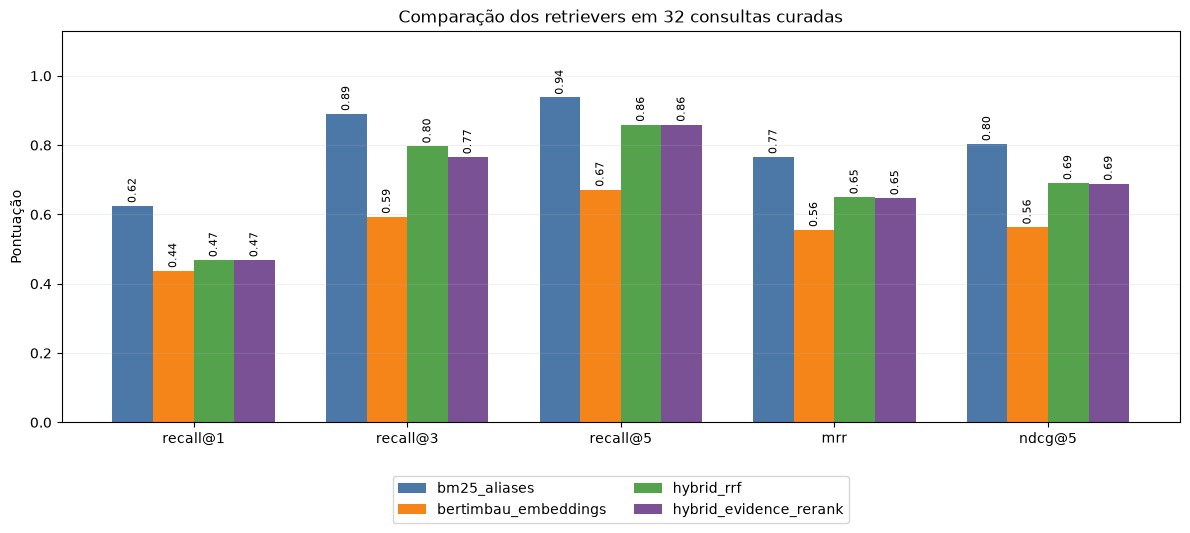

{'best_retriever': 'bm25_aliases', 'saved_report': 'reports\\metrics\\rag_retrieval_evaluation.json', 'saved_figure': 'reports\\figures\\rag_retrieval_comparison.png', 'saved_keyword_audit': 'reports\\metrics\\rag_keyword_audit.json'}


In [9]:
REPORT_PATH.write_text(json.dumps(report, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print({
    "best_retriever": best_retriever,
    "saved_report": str(REPORT_PATH.relative_to(ROOT)),
    "saved_figure": str(FIGURE_PATH.relative_to(ROOT)),
    "saved_keyword_audit": str(KEYWORD_AUDIT_PATH.relative_to(ROOT)),
})


## 11. Próximas evoluções

O melhor retriever desta rodada deve ser mantido como referência. Ainda precisamos revisar manualmente o conjunto de consultas, experimentar um modelo especializado em embeddings, separar fatos de inferências nos conteúdos mistos e adicionar datas reais de verificação das fontes antes de construir a geração final de respostas.

Os itens a seguir separam o que já foi demonstrado do que ainda depende de dados humanos, calibração ou evolução técnica. Assim, o notebook termina sem transformar resultados experimentais em garantias de produção.
